In [2]:
import pandas as pd
from datetime import datetime as dt, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_type = {
    "CustomerID": str  # converir en str pour éviter les problèmes de précision
}
df = pd.read_csv("./data/RFM Dataset/online_retail.csv", dtype=data_type, parse_dates=["InvoiceDate"])
df.dropna(subset=['CustomerID'], inplace=True)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB


# RFM avec Pandas

In [ ]:
# calcul du revenu
df["Revenu"] = df.Quantity * df.UnitPrice
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenu
284458,561873,21977,PACK OF 60 PINK PAISLEY CAKE CASES,1,2011-07-31 11:48:00,0.55,13316.0,United Kingdom,0.55
234523,557560,23284,DOORMAT KEEP CALM AND COME IN,2,2011-06-21 10:37:00,7.95,15329.0,United Kingdom,15.90
148692,549250,84997D,CHILDRENS CUTLERY POLKADOT PINK,2,2011-04-07 12:10:00,4.15,14446.0,United Kingdom,8.30
342722,566912,23133,LARGE IVORY HEART WALL ORGANISER,2,2011-09-15 14:05:00,8.25,14367.0,United Kingdom,16.50
76534,542629,22699,ROSES REGENCY TEACUP AND SAUCER,12,2011-01-31 09:57:00,2.95,12731.0,France,35.40


In [ ]:
# calcul de la date de référence (15 jours après la dernière transaction)
reference_date = df["InvoiceDate"].max()+timedelta(days = 15)

In [ ]:
# Grouper par CustomerID et calculer RFM
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate":lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "count",
    "Revenu": "sum"
})

In [9]:
rfm.rename(columns={
    "InvoiceDate":"Recency",
    "InvoiceNo": "Frequency",
    "Revenu": "Monetary"
}, inplace=True)

rfm.sample(5)

,Recency,Frequency,Monetary
CustomerID,,,
12674.0,26,91,1919.31
15826.0,65,69,1649.36
18223.0,16,299,6315.23
17969.0,180,14,228.20
17451.0,15,107,1648.95


In [ ]:
# Calcul des quintiles pour R, F et M
r = pd.qcut(rfm["Recency"], q= 5,labels=range(5,0,-1))
f = pd.qcut(rfm["Frequency"], q= 5,labels=range(1,6))
m = pd.qcut(rfm["Monetary"], q= 5,labels=range(1,6))

# Assignation des scrores R, F et M
    # Note: les scores de R sont inversés (5 = le plus récent, et 1 = le plus ancien)
    #       Les scrores de F et de M sont dans le sens normal ( 1 = le plus faible et 5 = les plus élévés)
    
rfm = rfm.assign(R = r.values, F = f.values, M = m.values)
rfm.sample(5)

,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
17633.0,45,72,1242.34,4,4,4
12962.0,21,16,266.39,5,2,2
16990.0,233,1,179.00,1,1,1
14064.0,43,82,1188.32,4,4,4
15182.0,168,29,622.85,2,2,3


In [ ]:
# Converir les scores R, F et M en string pour la création des segments
rfm["RFM_Segment"] = rfm["R"].astype(str)+rfm["F"].astype(str)+rfm["M"].astype(str)
rfm["RFM_Score"] = rfm[["R","F","M"]].sum(axis=1)

rfm.sample(5)

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
16612.0,47,66,1187.66,3,4,4,344,11
16232.0,47,38,983.23,3,3,4,334,10
13682.0,201,3,59.50,1,1,1,111,3
17560.0,109,27,854.95,2,2,3,223,7
16295.0,24,79,1328.55,5,4,4,544,13


In [ ]:
# Fonction pour assigner les segment RFM
def Assign_RFM_Segment(score):
    if score<5:
        return "Low-value"
    elif score<9:
        return "Mid-value"
    else :
        return "High-value"
    
rfm["RFM_Segment_label"]=rfm["RFM_Score"].apply(Assign_RFM_Segment)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,RFM_Segment_label
CustomerID,,,,,,,,,
12346.0,340,2,0.00,1,1,1,111,3,Low-value
12347.0,16,182,4310.00,5,5,5,555,15,High-value
12348.0,89,31,1797.24,2,3,4,234,9,High-value
12349.0,33,73,1757.55,4,4,4,444,12,High-value
12350.0,324,17,334.40,1,2,2,122,5,Mid-value


In [13]:
RFM_Segment_count = rfm["RFM_Segment_label"].value_counts()
RFM_Segment_count

RFM_Segment_label
High-value    2337
Mid-value     1492
Low-value      543
Name: count, dtype: int64

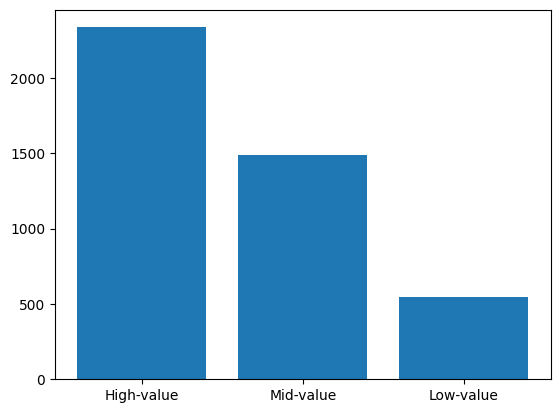

In [14]:
plt.bar(RFM_Segment_count.index, RFM_Segment_count.values)
plt.show()

# RFM avec Scikit-lean (Machine learnig : apprentissage non supervisé)

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [16]:
rfm_cluster = rfm[['Recency','Frequency',"Monetary"]]
rfm_cluster

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,340,2,0.00
12347.0,16,182,4310.00
12348.0,89,31,1797.24
12349.0,33,73,1757.55
12350.0,324,17,334.40
...,...,...,...
18280.0,292,10,180.60
18281.0,195,7,80.82
18282.0,22,13,176.60


In [17]:
scale = StandardScaler()
scale = scale.fit_transform(rfm_cluster)

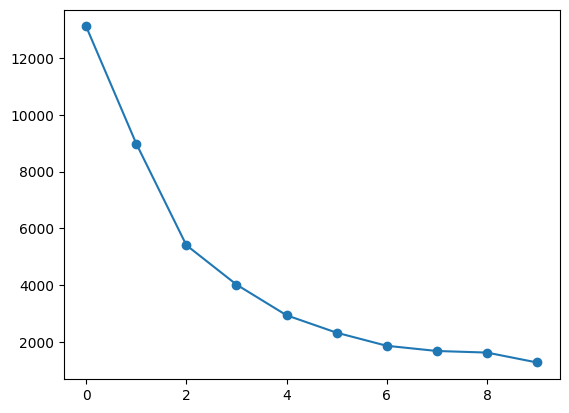

In [18]:
inertia = []

for i in range(1,11,1):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(scale)
    inertia.append(kmeans.inertia_)

plt.plot(inertia, marker="o")
plt.show()

In [19]:
kmean3 = KMeans(n_clusters=3)
kmean3.fit(scale)
rfm_cluster["Cluster"]=(kmean3.labels_+1)

rfm_cluster.sample(5)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21964\868964028.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_cluster["Cluster"]=(kmean3.labels_+1)


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
13485.0,247,23,454.24,3
14424.0,32,1,322.08,1
15184.0,43,63,406.76,1
12444.0,35,177,5005.46,1
13317.0,78,135,2140.07,1


In [20]:
cluster = rfm_cluster.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
cluster

,Recency,Frequency,Monetary
Cluster,,,
1,54.101258,104.988033,1953.027175
2,19.000000,2845.583333,118713.023333
3,260.757493,27.725704,463.754742


In [21]:
def Assign_RFM_Cluster(cluster):
    if cluster == 1:
        return "Mid-value"
    elif cluster == 2:
        return "Low-value"
    else :
        return "High-value"

In [22]:
rfm_cluster["RFM_Cluster_label"]= rfm_cluster["Cluster"].apply(Assign_RFM_Cluster)

rfm_cluster.sample(5)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21964\112826308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_cluster["RFM_Cluster_label"]= rfm_cluster["Cluster"].apply(Assign_RFM_Cluster)


,Recency,Frequency,Monetary,Cluster,RFM_Cluster_label
CustomerID,,,,,
17923.0,296,1,207.50,3,High-value
15632.0,30,177,3147.31,1,Mid-value
17491.0,15,110,3541.92,1,Mid-value
12936.0,31,63,1012.90,1,Mid-value
16270.0,367,54,1141.24,3,High-value


In [23]:
Plot = rfm[["Recency","Frequency", "Monetary"]]
Plot.sample(5)

,Recency,Frequency,Monetary
CustomerID,,,
16499.0,374,22,319.10
12541.0,44,52,981.18
14371.0,309,4,100.50
16923.0,26,696,6666.83
18004.0,376,40,169.47


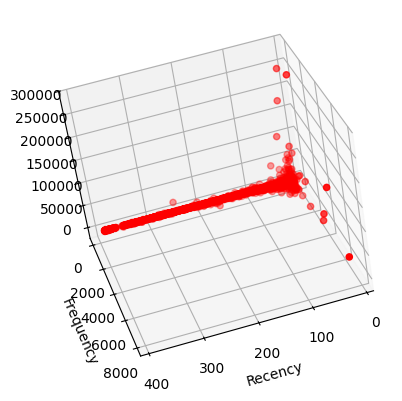

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

ax.scatter(rfm["Recency"],rfm["Frequency"], rfm["Monetary"], c="red")
ax.view_init(elev=30, azim=80, roll = 10 )

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_label("Monetary")

plt.show()

In [26]:
RFM_Cluster_count = rfm_cluster["RFM_Cluster_label"].value_counts()
RFM_Cluster_count

RFM_Cluster_label
Mid-value     3259
High-value    1101
Low-value       12
Name: count, dtype: int64

<Axes: ylabel='RFM_Cluster_label'>

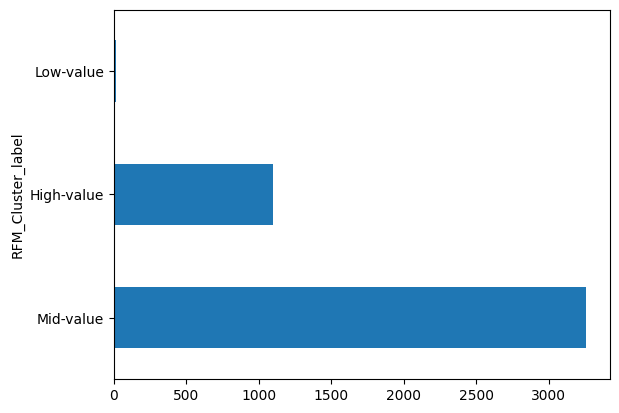

In [27]:
RFM_Cluster_count.plot(kind="barh")